In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

## Setup

### Utility Functions

In [3]:
def train(model: nn.Module, dataloader: DataLoader, nepochs:int = 100,) -> None:

    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

    loss_function = nn.CrossEntropyLoss()

    losses = []
    accuracies = []
    for epoch in tqdm(range(nepochs)):

        batch_losses, batch_accuracies = [], []
        for batch_idx, (features, labels) in enumerate(dataloader):

            optimizer.zero_grad()

            output = model.forward(features)

            loss = loss_function(output, labels)
            batch_losses.append(loss.item())

            loss.backward()

            optimizer.step()

            accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
            batch_accuracies.append(accuracy)

        losses.append(np.mean(batch_losses))
        accuracies.append(np.mean(batch_accuracies))

def test(model: nn.Module, dataloader: DataLoader) -> np.float32: 

    accuracies = []
    for batch_idx, (features, labels) in enumerate(dataloader):

        output = model(features)

        accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
        accuracies.append(accuracy)

    print(f'Accuracy = {np.mean(accuracies):.2f}')

    return np.mean(accuracies)

class utils:
    train = train
    test = test


### Load Data

In [5]:
url = 'https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv'
df = pd.read_csv(url)

# the data in the wine column are the labels
labels_orig = df['Wine'].values

# the data from all other columns are the features
features_orig = df.drop(columns='Wine').values

features_orig_tensor = torch.tensor(features_orig, dtype=torch.float32)
labels_orig_tensor = torch.tensor(labels_orig, dtype=torch.long)
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


Take a look at the numbers in the columns titled `Nonflavonoid.phenols` and `Proline` in the table above. The numbers in the `Nonflavonoid.phenols` are smaller than one while the numbers in the `Proline` column are in the hundreds to one thousand.[<sup>1</sup>](#fn1) When passing the features from this data through a neural network, the data from `Proline` column are going to influence the model more than the data from the `Nonflavonoid.phenols` column, simply because they are bigger. That can negatively impact the performance of the model as the `Proline` data aren't necessarily more important just because the numbers are bigger. To avoid this issue, it's a good idea to make sure that the different features have the same scale, and we can do that through standardizing or normalizing the data. In this notebook, you'll learn different techniques for standardization and normalization. 

<span id="fn1"><sup>1</sup>It's true for the numbers that aren't displayed as well. You can plot them in a histogram to check if you want. </span>

## Section 1: Standardization and Normalization of Data Can Improve Network Performance 

| Code | Description |
| :-- | :-- |
| `utils.train(model, nepochs=100, dataloader=train_dataloader)` | Train model with utility function. |
| `accuracy = utils.test(model, dataloader=test_dataloader)` | Test model with utility function. |
| `(data - data.min())/(data.max()-data.min())` | Normalize data. |
| `(data - data.mean())/data.std()` | Standardize data against mean. |
| `(data - torch.median(data))/data.std()` | Standardize data against median. |
| `(data - data.mean())/data.std()` | Standardize data against mean. |
| `data.mean(dim=0)` or `torch.mean(dim=0)` | Compute the mean over the first dimension in a multidimensional tensor. |
| `data.std(dim=0)` or `torch.std(dim=0)` | Compute the standard deviation over the first dimension in a multidimensional tensor. |
| `data.min(dim=0).values` or `torch.min(dim=0).values` | Compute the minimum over the first dimension in a multidimensional tensor. |
| `data.max(dim=0).values` or `torch.max(dim=0).values` | Compute the maximum over the first dimension in a multidimensional tensor. |


**Example**: Normalize the `proline` tensor provided in the cell below. Assign the normalized values to a variable named `norm_proline` and run the cell that plots a distribution of the `norm_proline` to check that its lower bound is `0` and upper bound is `1`.

In [67]:
proline = torch.tensor(df['Proline'].values)

In [68]:
norm_proline = (proline - proline.min())/(proline.max()-proline.min())

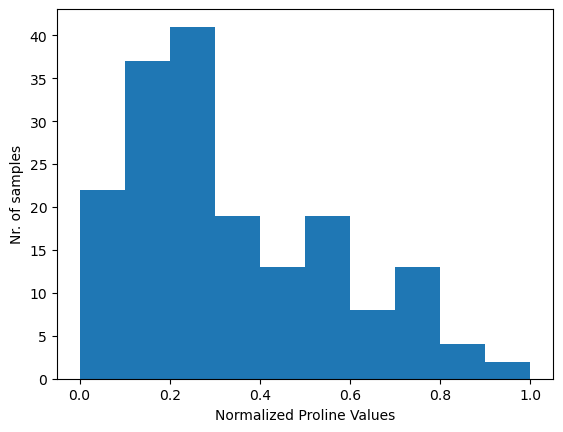

In [69]:
plt.hist(norm_proline)
plt.xlabel('Normalized Proline Values')
plt.ylabel('Nr. of samples');

**Exercise**: Normalize the `Nonflavonoid.phenols` data, which are assigned to the variable `non_ph` in the cell below. Assign the normalized values to a variable named `norm_non_ph` and run the cell that plots a distribution of the `norm_non_ph` to check that its lower bound is `0` and upper bound is `1`.

In [70]:
non_ph = torch.tensor(df['Nonflavanoid.phenols'].values, dtype=torch.float32)

norm_non_ph = (non_ph - non_ph.min())/(non_ph.max()-non_ph.min())

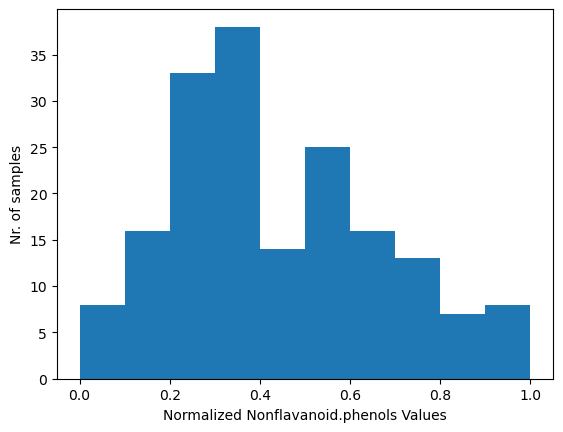

In [71]:
plt.hist(norm_non_ph)
plt.xlabel('Normalized Nonflavanoid.phenols Values')
plt.ylabel('Nr. of samples');

**Exercise**: Compute the normalized values of the tensor `features` provided below, which contains the data from both the `Proline` and the `Nonflavanoid.phenols` column. Assign the result to a variable named `features_norm` and run the cell making a boxplot for the two features after normalization to check that they are both bounded by `0` and `1`.

**Hint**: You need to specify the dimension along which the `min` and the `max` should be calculated - e.g. `dim=0`.

In [72]:
features = torch.tensor(df[['Proline','Nonflavanoid.phenols']].values, dtype=torch.float32)

In [73]:
features_norm = (features - features.min(dim=0).values)/(features.max(dim=0).values-features.min(dim=0).values)

Text(0, 0.5, 'Normalized Values')

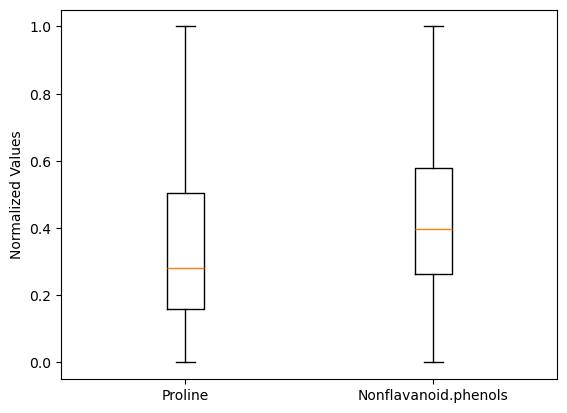

In [74]:
plt.boxplot(features_norm)
plt.xticks([1, 2], ['Proline', 'Nonflavanoid.phenols'])
plt.ylabel('Normalized Values')

**Exercise**: Compute the normalized values of the tensor `features` provided below, which contains the data from **all columns** except the `Wine` column. Assign the result to a variable named `features_norm` and run the cell making a boxplot for all features after normalization to check that all 13 features are bounded by `0` and `1`.

In [75]:
# the data from all other columns are the features
features = torch.tensor(df.drop(columns='Wine').values, dtype=torch.float32)

In [76]:
features_norm = (features - features.min(dim=0).values)/(features.max(dim=0).values-features.min(dim=0).values)

Text(0, 0.5, 'Normalized Values')

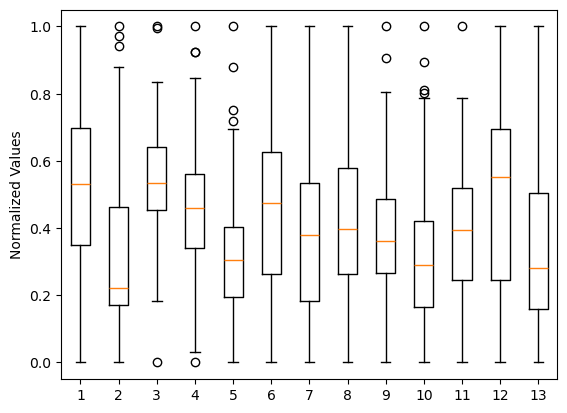

In [77]:
plt.boxplot(features_norm)
plt.ylabel('Normalized Values')

#### Demo: Effect of Scaling on Model Performance

Run the cells below and compare the accuracy of the model when trained with the original, non-normalized tensors to the accuracy when trained with normalized tensors.

Define Model

In [17]:
class Model(nn.Module):
    def __init__(self,):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Linear(16,13)
        )

    def forward(self, x):
        output = self.layers(x)
        return output
    
Model()

Model(
  (layers): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=13, bias=True)
  )
)

Set seed and create generator

In [18]:
SEED = 2025
generator = torch.Generator().manual_seed(SEED)

#### Train without Nomalizing Features

In [ ]:
# create dataset
dataset = TensorDataset(features_orig_tensor, labels_orig_tensor)

# split into train and test data
train_fraction = 0.8
test_fraction = 1-train_fraction
train_data, test_data = random_split(dataset, lengths=[train_fraction, test_fraction], generator=generator)

# create data loader
train_dataloader = DataLoader(train_data, batch_size=20, drop_last=True)
# instantiate model
torch.manual_seed(SEED)
model = Model()

# train model
utils.train(model, nepochs=100, dataloader=train_dataloader)

100%|██████████| 100/100 [00:02<00:00, 44.99it/s]


Test Performance of Model **without Normalization**

In [ ]:
test_dataloader = DataLoader(test_data, batch_size=len(test_data))
accuracy_nonnorm = test(model, dataloader=test_dataloader)

Accuracy = 0.77


#### Train without Nomalizing Features

In [22]:
# normalize features
features_norm_tensor = torch.tensor(MinMaxScaler().fit_transform(features_orig), dtype=torch.float32)

# create dataset
dataset = TensorDataset(features_norm_tensor, labels_orig_tensor)

# split into train and test data
train_fraction = 0.8
test_fraction = 0.2
train_data, test_data = random_split(dataset, lengths=[train_fraction, test_fraction], generator=generator)

# create data loader
train_dataloader = DataLoader(train_data, batch_size=20, drop_last=True)

# instantiate model
torch.manual_seed(SEED)
model = Model()

# train model
utils.train(model, nepochs=100, dataloader=train_dataloader)

  3%|▎         | 3/100 [00:00<00:03, 28.35it/s]

100%|██████████| 100/100 [00:01<00:00, 58.23it/s]


Test Performance of Model **with Normalization**

In [23]:
test_dataloader = DataLoader(test_data, batch_size=len(test_data))
accuracy_norm = test(model, dataloader=test_dataloader)

Accuracy = 1.00


Text(0, 0.5, 'Accuracy (%)')

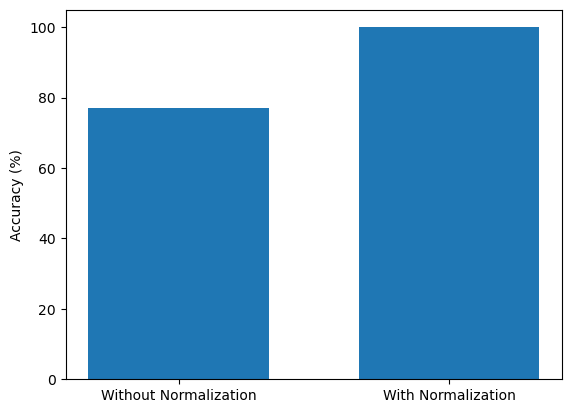

In [48]:
plt.bar([0,0.3], np.array([accuracy_nonnorm, accuracy_norm])*100, width=[0.2])
plt.xticks([0,0.3], labels=['Without Normalization', 'With Normalization'])
plt.ylim([0.,105])
plt.ylabel('Accuracy (%)')

The model performance improved by more than 20 percentage points simply by normalizing the features!

**Exercise**: Standarize the `alcohol` tensor provided in the cell below. Assign the standardized values to a variable named `z_alcohol` and run the cell that plots a distribution of the `z_alcohol` to do a rough visual check of whether it's a normal distribution or not (i.e. bell curve centered around 0).

In [64]:
alcohol = torch.tensor(df['Alcohol'].values, dtype=torch.float32)

z_alcohol = (alcohol - alcohol.mean())/alcohol.std()

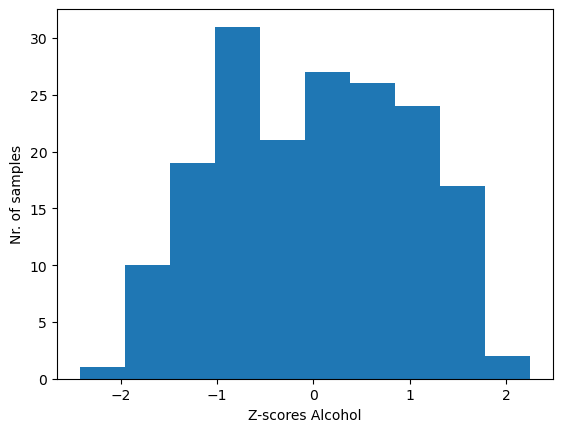

In [66]:
plt.hist(z_alcohol)
plt.xlabel('Z-scores Alcohol')
plt.ylabel('Nr. of samples');

In [ ]:
df.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

**Exercise**: Standardize 

In [52]:
df.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

## Section 2: Standardization Should be picked wisely

## Section 3: `sklearn.preprocessing` is super helpful

## Section 4: `sklearn.pipeline` wraps all this nicely